Importing the Dependencies


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Data Collection and Processing


In [2]:
# Loading data from csv file to Pandas Dataframe
calories = pd.read_csv('/content/calories.csv')

In [3]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [4]:
exercise = pd.read_csv('/content/exercise.csv')

In [5]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


Combining the Dataframes


In [6]:
calories_data = pd.concat([exercise,calories['Calories']],axis=1)

In [7]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [8]:
#Checking the number of rows and columns
calories_data.shape

(15000, 9)

In [9]:
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [10]:
calories_data.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


Data Analysis


In [11]:
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Data Visualization

In [12]:
sns.set()

<Axes: xlabel='count', ylabel='Gender'>

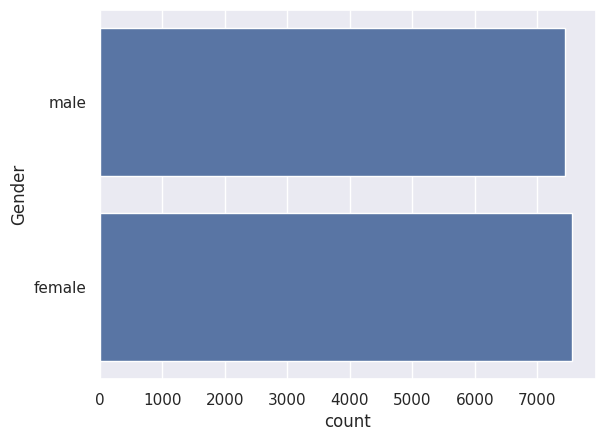

In [13]:
#Plotting the gender column in count plot
sns.countplot(calories_data['Gender'])

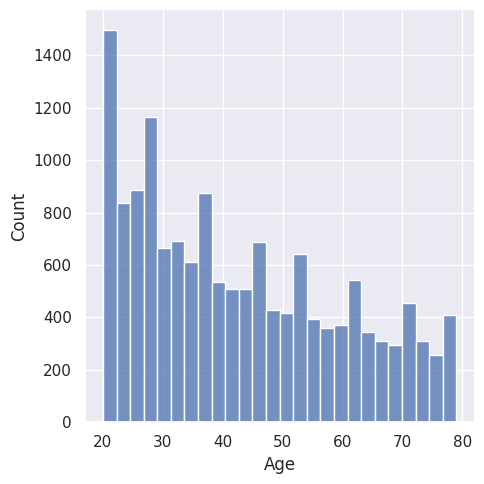

In [14]:
#Finding the distribution of "Age" column
sns.displot(calories_data['Age'])

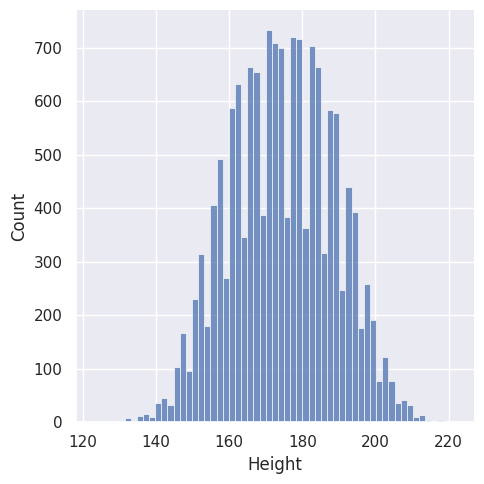

In [15]:
#Finding the distribution of "Height" column
sns.displot(calories_data['Height'])

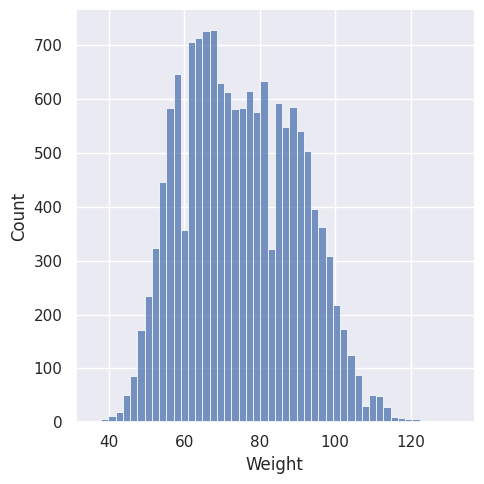

In [16]:
#Finding the distribution of "Weight" column
sns.displot(calories_data['Weight'])

Finding the Correalation in Dataset

In [17]:
correlation=calories_data.corr(numeric_only=True)

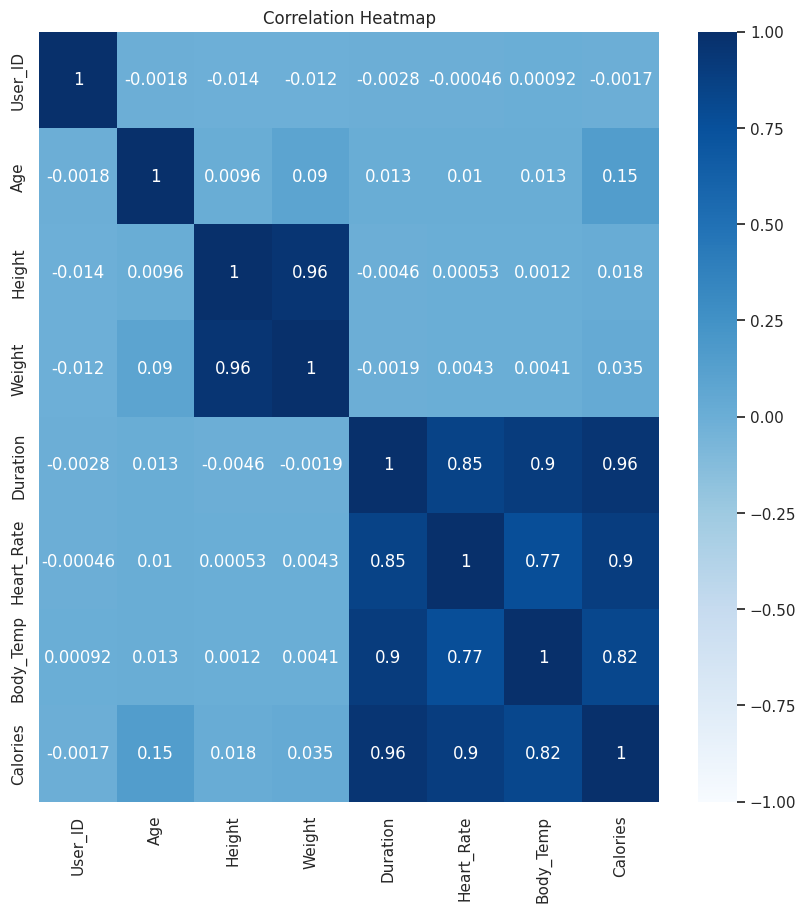

In [18]:
plt.figure(figsize=(10, 10))
sns.heatmap(correlation,
            annot=True,          # Show correlation values in cells
            cmap='Blues',     # Use a diverging color map
            vmin=-1, vmax=1,# Set color limits
            )
plt.title('Correlation Heatmap')
plt.show()

Converting the text data to numerical

In [19]:
calories_data.replace({"Gender":{'male':0,'female':1}}, inplace=True)

/tmp/ipykernel_859/2713499166.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({"Gender":{'male':0,'female':1}}, inplace=True)


In [20]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


Seperating features and Target

In [22]:
X = calories_data.drop(columns=['User_ID','Calories'],axis=1)
Y = calories_data['Calories']

In [23]:
print(X)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [24]:
print(Y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


Splitting the data into training data and Test data

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [27]:
print(X.shape, X_train.shape, X_test.shape)

(15000, 7) (12000, 7) (3000, 7)


Model Training

XGBoost Regressor

In [28]:
model = XGBRegressor()

In [29]:
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Prediction on Test Data

In [30]:
test_data_prediction = model.predict(X_test)

In [31]:
print(test_data_prediction)

[125.58828  222.11377   38.725952 ... 144.3179    23.425894  90.100494]


Mean Absolute Error

In [32]:
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)

In [33]:
print("Mean Absolute Error= ",mae)

Mean Absolute Error=  1.4833678883314132


Predictive System

In [54]:
import joblib

# Replace 'model' with whatever you named your XGBRegressor variable
joblib.dump(model, 'calorie_predictor_model.pkl')
print("SUCCESS: Your XGBRegressor model is now saved into the file!")

SUCCESS: Your XGBRegressor model is now saved into the file!


In [68]:
import pandas as pd

def live_calorie_predictor(duration, heart_rate, age, weight, gender, height):
    # Hardcode body_temp so the user doesn't have to provide it
    body_temp = 37.5

    # 2. Build the dataframe
    input_data = {
        'Gender': [gender],
        'Age': [age],
        'Height': [height],
        'Weight': [weight],
        'Duration': [duration],
        'Heart_Rate': [heart_rate],
        'Body_Temp': [body_temp]
    }

    # 3. Predict and return
    input_df = pd.DataFrame(input_data)
    return model.predict(input_df)[0]

In [69]:
result = live_calorie_predictor(duration=45, heart_rate=150, age=22, weight=90 ,gender=1, height=180)
print(f"🔥 Successfully Predicted Calories: {result} kcal")

🔥 Successfully Predicted Calories: 246.22023010253906 kcal


In [70]:
result = live_calorie_predictor(duration=40, heart_rate=110, age=22, weight=91 ,gender=1, height=152)
print(f"🔥 Successfully Predicted Calories: {result} kcal")

🔥 Successfully Predicted Calories: 185.74853515625 kcal


In [71]:
result = live_calorie_predictor(duration=10, heart_rate=85, age=32, weight=75 ,gender=0, height=164)
print(f"🔥 Successfully Predicted Calories: {result} kcal")

🔥 Successfully Predicted Calories: 26.51320457458496 kcal


In [72]:
result = live_calorie_predictor(duration=25, heart_rate=115, age=42, weight=65 ,gender=0, height=160)
print(f"🔥 Successfully Predicted Calories: {result} kcal")

🔥 Successfully Predicted Calories: 203.7764434814453 kcal
